# 03 — Exact Additive GP fitted to Norwegian births 1966–2024 (SVI)

**Project:** Bayesian GP decomposition of Norwegian live births 1966–2025  
**Course:** 42186 Model-Based Machine Learning, DTU Spring 2026  

Run `01_baselines.ipynb` (produces `norway_births_monthly.csv` and `01_eval_baselines.csv`) and `02_synthetic_recovery.ipynb` (validates the model on synthetic data).

**This notebook:**
1. Loads the real 1966–2025 data (train: 1966-01 – 2024-12; test: 2025-01 – 2025-12).
2. Fits the full additive GP (Matérn trend + Periodic×RBF seasonal + RBF short-term, NegBin likelihood) with SVI (`AutoNormal` mean-field guide).
3. Produces the component decomposition, variance breakdown, and 2025 forecast.
4. Evaluates against the baselines from notebook 01 in a consolidated table.

SVI with mean-field `AutoNormal` is the primary inference method for this project. The mean-field approximation ignores posterior correlations between neighbouring time points, so uncertainty in smooth components is likely underestimated; this is acknowledged as a limitation in the report.

## 0. Imports

In [81]:
from pathlib import Path
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import torch
import pyro
import pyro.distributions as dist
from pyro.infer import SVI, Trace_ELBO, Predictive
from pyro.optim import ClippedAdam
import pyro.infer.autoguide as autoguide
from scipy.stats import norm as scipy_norm

pyro.set_rng_seed(2026)
torch.manual_seed(2026)
PROJ = Path(".")
print("Pyro", pyro.__version__, "| Torch", torch.__version__)

Pyro 1.9.1 | Torch 2.8.0


## 1. Data loading

In [82]:
df = pd.read_csv(PROJ / "norway_births_monthly.csv", parse_dates=["date"])

train = df[df["year"] <= 2024].copy().reset_index(drop=True)
test  = df[df["year"] == 2025].copy().reset_index(drop=True)

print(f"Train: {len(train)} months  ({train.year.min()}–{train.year.max()})")
print(f"Test : {len(test)} months  ({test.year.min()})")

LOG_MEAN_REAL = float(train["log_births"].mean())
print(f"\nlog mean (train) = {LOG_MEAN_REAL:.4f}  ≈ {np.exp(LOG_MEAN_REAL):.0f} births/month")

# ---- tensors ----
# Joint time vector: train first, then test — ordering matters for the Cholesky extrapolation
t_train = torch.tensor(train["t"].values, dtype=torch.float32)
t_test  = torch.tensor(test["t"].values,  dtype=torch.float32)
t_all   = torch.cat([t_train, t_test])         # (720,)

y_train = torch.tensor(train["births"].values, dtype=torch.float32)
y_test  = torch.tensor(test["births"].values,  dtype=torch.float32)

N_TRAIN = len(t_train)   # 708
N_TEST  = len(t_test)    # 12
N_ALL   = len(t_all)     # 720
print(f"N_TRAIN={N_TRAIN}, N_TEST={N_TEST}, N_ALL={N_ALL}")

Train: 708 months  (1966–2024)
Test : 12 months  (2025)

log mean (train) = 8.4733  ≈ 4785 births/month
N_TRAIN=708, N_TEST=12, N_ALL=720


## 2. Kernel functions

Identical to notebook 02, repeated here so this notebook is self-contained.

In [83]:
JITTER = 1e-4

def k_matern52(x1, x2, lengthscale):
    r = (x1.unsqueeze(-1) - x2.unsqueeze(-2)).abs()
    z = (5.0 ** 0.5) * r / lengthscale
    return (1.0 + z + z.pow(2) / 3.0) * (-z).exp()

def k_rbf(x1, x2, lengthscale):
    r2 = (x1.unsqueeze(-1) - x2.unsqueeze(-2)).pow(2)
    return (-0.5 * r2 / lengthscale.pow(2)).exp()

def k_periodic(x1, x2, lengthscale, period=1.0):
    dt = (x1.unsqueeze(-1) - x2.unsqueeze(-2)).abs()
    return (-2.0 * (torch.pi * dt / period).sin().pow(2) / lengthscale.pow(2)).exp()

## 3. Additive GP model

**Key design:** `t_all` (720 points = 708 train + 12 test) is passed in; the GP priors cover all 720 points. The NegBin likelihood conditions only on the first `N_TRAIN` outputs. The Cholesky structure then encodes the GP-conditional relationship between train and test function values, so posterior samples at test points give the correct GP extrapolation without any extra conditioning step.

**Whitened parameterization:** `z_k ~ N(0,I)`, `f_k = L_k(θ) @ z_k`. Keeps the guide simple (just learns the posterior mean/variance of each `z` element).

In [84]:
def additive_gp_model(t, y_train=None, n_train=None):
    """
    t       : (N_ALL,) time vector covering train + test
    y_train : (N_TRAIN,) observed counts; None for prior/posterior predictive
    n_train : number of training observations (len(y_train) when not None)
    """
    n = len(t)
    n_obs = n_train if n_train is not None else (len(y_train) if y_train is not None else n)
    I = torch.eye(n)

    # ---- hyperparameter priors ----
    # ell_trend = pyro.sample("ell_trend", dist.InverseGamma(torch.tensor(6.0),  torch.tensor(30.0)))
    ell_trend = pyro.sample("ell_trend", dist.InverseGamma(torch.tensor(3.0), torch.tensor(10.0)))
    # sig_trend = pyro.sample("sig_trend", dist.HalfNormal(torch.tensor(0.3)))

    ell_p    = pyro.sample("ell_p",    dist.HalfNormal(torch.tensor(1.0)))
    ell_s    = pyro.sample("ell_s",    dist.InverseGamma(torch.tensor(6.0),  torch.tensor(60.0)))
    sig_seas = pyro.sample("sig_seas", dist.HalfNormal(torch.tensor(0.15)))

    ell_short = pyro.sample("ell_short", dist.InverseGamma(torch.tensor(3.0), torch.tensor(0.5)))
    # sig_short = pyro.sample("sig_short", dist.HalfNormal(torch.tensor(0.15)))

    sig_trend = pyro.sample("sig_trend", dist.HalfNormal(torch.tensor(0.1)))
    sig_short = pyro.sample("sig_short", dist.HalfNormal(torch.tensor(0.1)))

    # c     = pyro.sample("c",     dist.Normal(torch.tensor(LOG_MEAN_REAL), torch.tensor(1.0)))
    c = pyro.sample("c", dist.Normal(torch.tensor(LOG_MEAN_REAL), torch.tensor(0.05)))
    # alpha = pyro.sample("alpha", dist.Gamma(torch.tensor(2.0), torch.tensor(0.1)))
    alpha = pyro.sample("alpha", dist.Gamma(torch.tensor(10.0), torch.tensor(0.1)))

    # Clamp lengthscales to prevent near-singular kernel matrices
    ell_trend = ell_trend.clamp(min=0.1)
    ell_p     = ell_p.clamp(min=0.05)
    ell_s     = ell_s.clamp(min=1.0)
    ell_short = ell_short.clamp(min=0.02)

    # ---- kernel matrices (over all N_ALL time points) ----
    K_trend = sig_trend**2 * k_matern52(t, t, ell_trend)                        + JITTER * I
    K_seas  = sig_seas**2  * k_periodic(t, t, ell_p) * k_rbf(t, t, ell_s)      + JITTER * I
    K_short = sig_short**2 * k_rbf(t, t, ell_short)                             + JITTER * I

    L_trend = torch.linalg.cholesky(K_trend)
    L_seas  = torch.linalg.cholesky(K_seas)
    L_short = torch.linalg.cholesky(K_short)

    # ---- whitened latent samples ----
    z_trend = pyro.sample("z_trend", dist.Normal(torch.zeros(n), torch.ones(n)).to_event(1))
    z_seas  = pyro.sample("z_seas",  dist.Normal(torch.zeros(n), torch.ones(n)).to_event(1))
    z_short = pyro.sample("z_short", dist.Normal(torch.zeros(n), torch.ones(n)).to_event(1))

    f_trend = L_trend @ z_trend
    f_seas  = L_seas  @ z_seas
    f_short = L_short @ z_short
    f       = f_trend + f_seas + f_short

    mu = (f + c).exp()

    # Condition only on training observations
    with pyro.plate("obs", n_obs):
        pyro.sample(
            "y",
            dist.GammaPoisson(concentration=alpha, rate=alpha / mu[:n_obs]),
            obs=y_train,
        )


# Smoke-test: one prior forward pass
torch.manual_seed(0)
with torch.no_grad():
    tr = pyro.poutine.trace(additive_gp_model).get_trace(
        t_all, y_train, N_TRAIN
    )
latent_sites = [s for s in tr.nodes if tr.nodes[s]["type"] == "sample"]
print("Latent sites:", latent_sites)

Latent sites: ['ell_trend', 'ell_p', 'ell_s', 'sig_seas', 'ell_short', 'sig_trend', 'sig_short', 'c', 'alpha', 'z_trend', 'z_seas', 'z_short', 'obs', 'y']


## 4. Prior predictive check

Sample 200 forward passes before seeing data. Generated curves should look loosely like Norwegian births (right order of magnitude, roughly seasonal). If the prior predictive is absurd, the priors need adjusting.

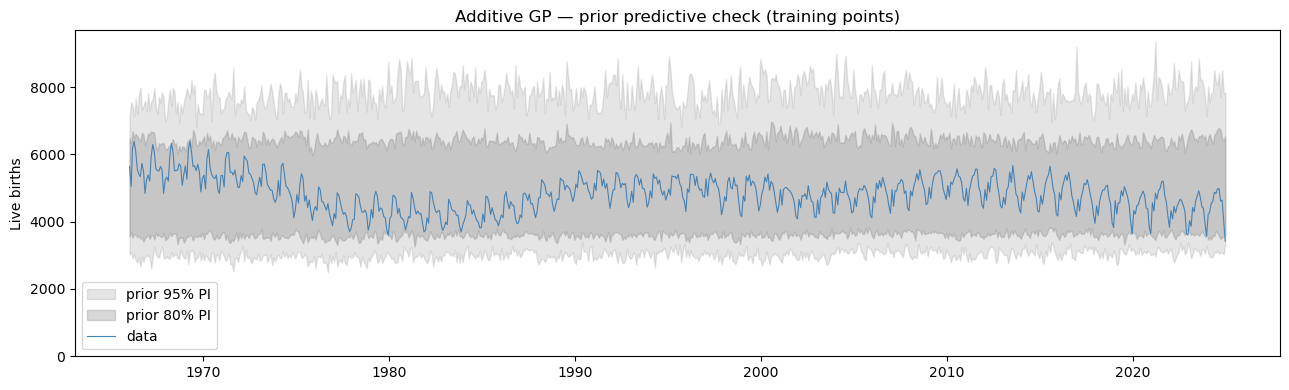

Prior 95% PI contains observed data fraction: 1.00


In [85]:
torch.manual_seed(2026)
prior_pred = Predictive(additive_gp_model, num_samples=200)(
    t_all, None, N_TRAIN
)
prior_y = prior_pred["y"].float().numpy()  # (200, 708) — only training indices observed

fig, ax = plt.subplots(figsize=(13, 4))
ax.fill_between(
    train["date"],
    np.percentile(prior_y, 2.5,  axis=0),
    np.percentile(prior_y, 97.5, axis=0),
    alpha=0.2, color="grey", label="prior 95% PI",
)
ax.fill_between(
    train["date"],
    np.percentile(prior_y, 10, axis=0),
    np.percentile(prior_y, 90, axis=0),
    alpha=0.3, color="grey", label="prior 80% PI",
)
ax.plot(train["date"], train["births"], color="steelblue", lw=0.8, zorder=5, label="data")
ax.set_ylim(0, None)
ax.set_title("Additive GP — prior predictive check (training points)")
ax.set_ylabel("Live births")
ax.legend()
plt.tight_layout()
plt.savefig(PROJ / "03_prior_predictive.png", dpi=120, bbox_inches="tight")
plt.show()

print(f"Prior 95% PI contains observed data fraction: "
      f"{np.mean((train['births'].values >= np.percentile(prior_y, 2.5, 0)) & (train['births'].values <= np.percentile(prior_y, 97.5, 0))):.2f}")

## 5. SVI inference

`AutoNormal` mean-field guide: one Normal per latent dimension. At n=720 and 3 whitened GP components, the guide has ≈ 4338 variational parameters.

**Expected runtime:** ~5–15 min on CPU depending on hardware (three 720×720 Cholesky factorizations per step).

In [86]:
pyro.clear_param_store()
torch.manual_seed(2026)

guide = autoguide.AutoNormal(additive_gp_model)
svi = SVI(additive_gp_model, guide, ClippedAdam({"lr": 0.02, "clip_norm": 10.0}), loss=Trace_ELBO())

N_STEPS = 8000
losses  = []
t0 = time.time()

for step in range(N_STEPS):
    # Drop learning rate at halfway point by replacing the optimizer
    if step == N_STEPS // 2:
        svi = SVI(additive_gp_model, guide, ClippedAdam({"lr": 0.005, "clip_norm": 10.0}), loss=Trace_ELBO())
        print(f"  [step {step}] LR reduced to 0.005")

    loss = svi.step(t_all, y_train, N_TRAIN)
    losses.append(loss)

    if step % 1000 == 0 or step == N_STEPS - 1:
        elapsed = time.time() - t0
        print(f"step {step:5d}  ELBO = {-loss:10.1f}  ({elapsed:.0f}s elapsed)")

print(f"\nTotal SVI time: {time.time()-t0:.0f}s")

step     0  ELBO = -2054004.6  (0s elapsed)
step  1000  ELBO =    -4955.4  (35s elapsed)
step  2000  ELBO =    -5066.2  (70s elapsed)
step  3000  ELBO =    -5105.8  (105s elapsed)
  [step 4000] LR reduced to 0.005
step  4000  ELBO =    -4976.5  (140s elapsed)
step  5000  ELBO =    -5021.5  (174s elapsed)
step  6000  ELBO =    -4874.3  (210s elapsed)
step  7000  ELBO =    -4933.3  (245s elapsed)
step  7999  ELBO =    -5049.7  (283s elapsed)

Total SVI time: 283s


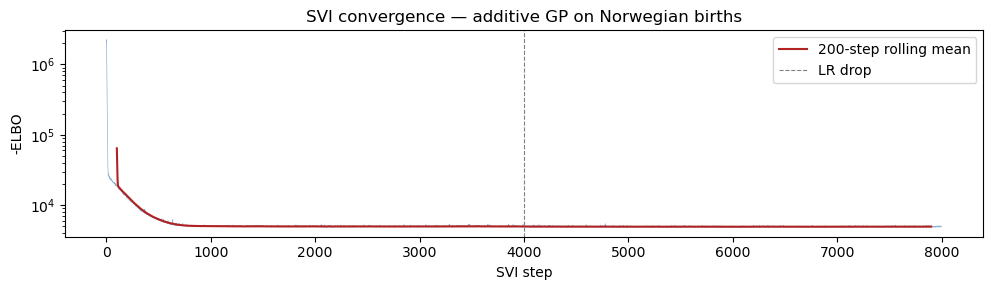

In [87]:
fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(losses, lw=0.5, alpha=0.6, color="steelblue")
smooth = pd.Series(losses).rolling(200, center=True).mean()
ax.plot(smooth, lw=1.5, color="firebrick", label="200-step rolling mean")
ax.axvline(N_STEPS // 2, color="grey", ls="--", lw=0.8, label="LR drop")
ax.set_xlabel("SVI step")
ax.set_ylabel("-ELBO")
ax.set_title("SVI convergence — additive GP on Norwegian births")
ax.legend()
plt.tight_layout()
plt.savefig(PROJ / "03_svi_convergence.png", dpi=120, bbox_inches="tight")
ax.set_yscale("log")
plt.show()

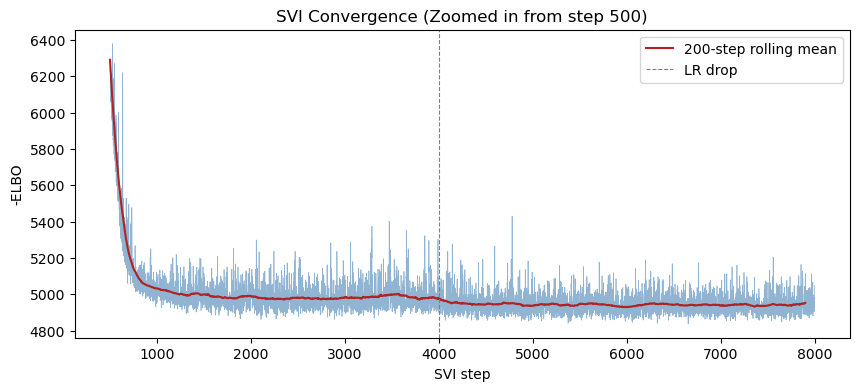

In [88]:
fig, ax = plt.subplots(figsize=(10, 4))

#plotting from step 500 and onward to zoom in on the later part of convergence
ax.plot(range(500, N_STEPS), losses[500:], lw=0.5, alpha=0.6, color="steelblue")

smooth = pd.Series(losses).rolling(200, center=True).mean()
ax.plot(range(500, N_STEPS), smooth[500:], lw=1.5, color="firebrick", label="200-step rolling mean")

ax.axvline(N_STEPS // 2, color="grey", ls="--", lw=0.8, label="LR drop")
ax.set_title("SVI Convergence (Zoomed in from step 500)")
ax.set_xlabel("SVI step")
ax.set_ylabel("-ELBO")
ax.legend()
plt.show()

## 6. Posterior samples

Draw 1000 posterior samples. We record all hyperparameters and all three `z` vectors so we can reconstruct the individual component functions.

In [89]:
torch.manual_seed(2026)
N_POST = 1000

post = Predictive(
    additive_gp_model, guide=guide,
    num_samples=N_POST,
    return_sites=[
        "y",
        "z_trend", "z_seas", "z_short",
        "ell_trend", "sig_trend",
        "ell_p", "ell_s", "sig_seas",
        "ell_short", "sig_short",
        "c", "alpha",
    ],
)(t_all, None, N_TRAIN)  # obs=None → posterior predictive

y_post_all = post["y"].float().numpy()   # (1000, 708) — only obs sites
print("Posterior y shape:", y_post_all.shape)

Posterior y shape: (1000, 708)


## 7. Component decomposition

Reconstruct `f_trend`, `f_seas`, `f_short` for all 720 time points using the per-sample hyperparameters and z values. This is the same `post_components` routine from notebook 02, applied to the full 720-point time grid.

In [90]:
def post_components(post_samples, t, n_show=200):
    """Compute component functions for the first n_show posterior samples."""
    n = len(t)
    I = torch.eye(n)
    f_trends, f_seass, f_shorts = [], [], []

    for i in range(n_show):
        ell_tr = post_samples["ell_trend"][i]
        sig_tr = post_samples["sig_trend"][i]
        ell_p  = post_samples["ell_p"][i]
        ell_s  = post_samples["ell_s"][i]
        sig_s  = post_samples["sig_seas"][i]
        ell_sh = post_samples["ell_short"][i]
        sig_sh = post_samples["sig_short"][i]

        K_tr = sig_tr**2 * k_matern52(t, t, ell_tr) + JITTER * I
        K_se = sig_s**2  * k_periodic(t, t, ell_p) * k_rbf(t, t, ell_s) + JITTER * I
        K_sh = sig_sh**2 * k_rbf(t, t, ell_sh)     + JITTER * I

        L_tr = torch.linalg.cholesky(K_tr)
        L_se = torch.linalg.cholesky(K_se)
        L_sh = torch.linalg.cholesky(K_sh)

        f_trends.append((L_tr @ post_samples["z_trend"][i].squeeze()).detach().numpy())
        f_seass.append( (L_se @ post_samples["z_seas"][i].squeeze()).detach().numpy())
        f_shorts.append((L_sh @ post_samples["z_short"][i].squeeze()).detach().numpy())

    return np.array(f_trends), np.array(f_seass), np.array(f_shorts)


print("Reconstructing component posteriors (200 samples)...")
t1 = time.time()
f_tr_post, f_se_post, f_sh_post = post_components(post, t_all, n_show=200)
print(f"Done in {time.time()-t1:.0f}s.")
print("Component arrays shape:", f_tr_post.shape)  # (200, 720)

Reconstructing component posteriors (200 samples)...
Done in 2s.
Component arrays shape: (200, 720)


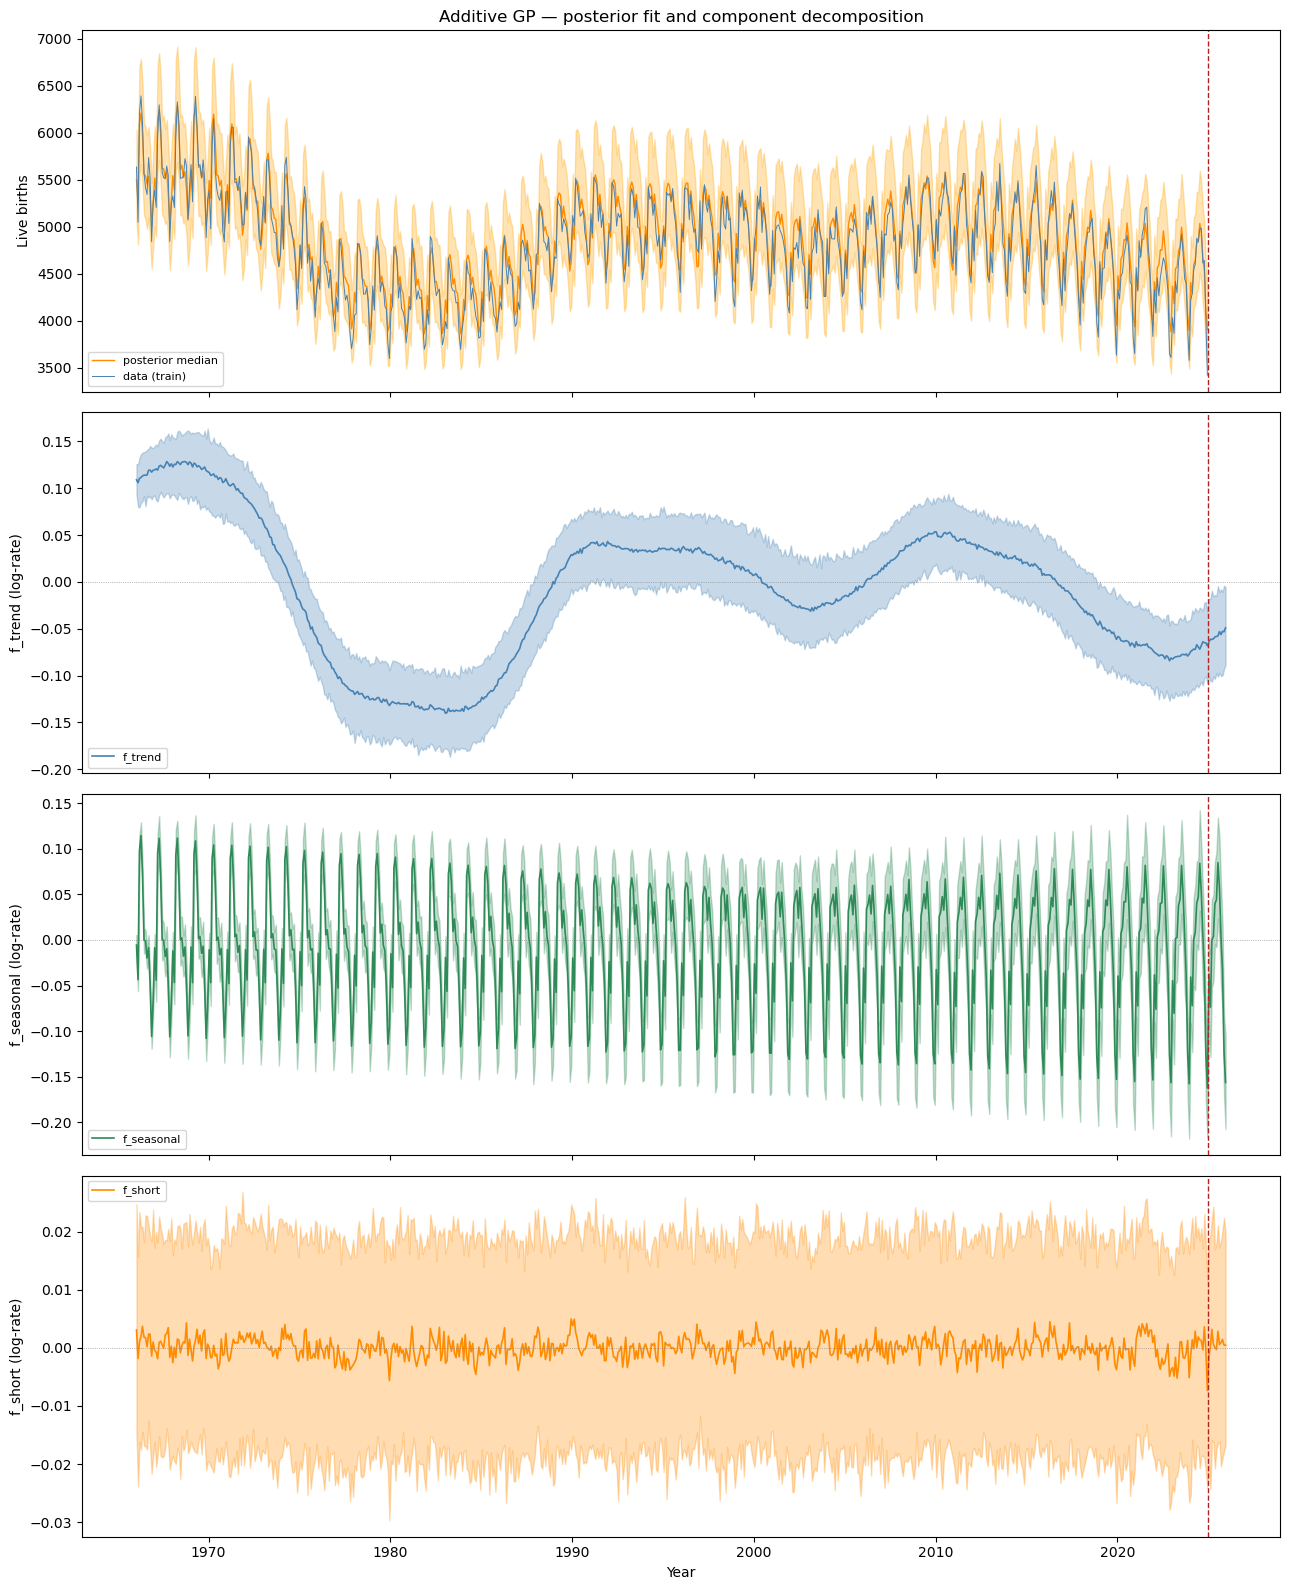

In [91]:
# Full date axis for all 720 points
dates_all = pd.concat([train["date"], test["date"]], ignore_index=True)
split_date = pd.Timestamp("2025-01-01")

# Posterior predictive on training set (from y_post_all)
fig, axes = plt.subplots(4, 1, figsize=(13, 16), sharex=True)

def shade_ci(ax, dates, lo, hi, color, alpha=0.3):
    ax.fill_between(dates, lo, hi, alpha=alpha, color=color)

# Panel 0: data + posterior predictive fit
ax = axes[0]
shade_ci(ax, train["date"], np.percentile(y_post_all, 2.5, 0), np.percentile(y_post_all, 97.5, 0), "orange")
ax.plot(train["date"], np.median(y_post_all, axis=0), color="darkorange", lw=1.0, label="posterior median")
ax.plot(train["date"], train["births"], color="steelblue", lw=0.7, label="data (train)")
ax.axvline(split_date, color="firebrick", ls="--", lw=1.0)
ax.set_ylabel("Live births")
ax.set_title("Additive GP — posterior fit and component decomposition")
ax.legend(fontsize=8)

# Panel 1: trend
ax = axes[1]
shade_ci(ax, dates_all, np.percentile(f_tr_post, 2.5, 0), np.percentile(f_tr_post, 97.5, 0), "steelblue")
ax.plot(dates_all, np.median(f_tr_post, 0), color="steelblue", lw=1.2, label="f_trend")
ax.axhline(0, color="grey", lw=0.5, ls=":")
ax.axvline(split_date, color="firebrick", ls="--", lw=1.0)
ax.set_ylabel("f_trend (log-rate)")
ax.legend(fontsize=8)

# Panel 2: seasonal
ax = axes[2]
shade_ci(ax, dates_all, np.percentile(f_se_post, 2.5, 0), np.percentile(f_se_post, 97.5, 0), "seagreen")
ax.plot(dates_all, np.median(f_se_post, 0), color="seagreen", lw=1.2, label="f_seasonal")
ax.axhline(0, color="grey", lw=0.5, ls=":")
ax.axvline(split_date, color="firebrick", ls="--", lw=1.0)
ax.set_ylabel("f_seasonal (log-rate)")
ax.legend(fontsize=8)

# Panel 3: short-term
ax = axes[3]
shade_ci(ax, dates_all, np.percentile(f_sh_post, 2.5, 0), np.percentile(f_sh_post, 97.5, 0), "darkorange")
ax.plot(dates_all, np.median(f_sh_post, 0), color="darkorange", lw=1.2, label="f_short")
ax.axhline(0, color="grey", lw=0.5, ls=":")
ax.axvline(split_date, color="firebrick", ls="--", lw=1.0)
ax.set_ylabel("f_short (log-rate)")
ax.set_xlabel("Year")
ax.legend(fontsize=8)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

plt.tight_layout()
plt.savefig(PROJ / "03_component_decomposition.png", dpi=120, bbox_inches="tight")
plt.show()

## 8. Variance decomposition

Fraction of total posterior variance on the log-rate scale explained by each component, averaged over training time points.

In [92]:
# Use only training indices for the variance decomposition
f_tr_train = f_tr_post[:, :N_TRAIN]   # (200, 708)
f_se_train = f_se_post[:, :N_TRAIN]
f_sh_train = f_sh_post[:, :N_TRAIN]
f_total    = f_tr_train + f_se_train + f_sh_train

# Variance of each component across time (mean over posterior samples, then across time)
var_tr  = float(np.var(f_tr_train, axis=0).mean())
var_se  = float(np.var(f_se_train, axis=0).mean())
var_sh  = float(np.var(f_sh_train, axis=0).mean())
var_tot = float(np.var(f_total, axis=0).mean())

var_df = pd.DataFrame([
    {"Component": "Trend (Matérn-5/2)",      "Var (log-rate)": round(var_tr, 5), "% of total": round(100*var_tr/var_tot, 1)},
    {"Component": "Seasonal (Periodic×RBF)", "Var (log-rate)": round(var_se, 5), "% of total": round(100*var_se/var_tot, 1)},
    {"Component": "Short-term (RBF)",         "Var (log-rate)": round(var_sh, 5), "% of total": round(100*var_sh/var_tot, 1)},
    {"Component": "Total",                    "Var (log-rate)": round(var_tot, 5), "% of total": 100.0},
]).set_index("Component")

print(var_df.to_string())

                         Var (log-rate)  % of total
Component                                          
Trend (Matérn-5/2)              0.00043        48.8
Seasonal (Periodic×RBF)         0.00035        39.7
Short-term (RBF)                0.00010        11.3
Total                           0.00089       100.0


## 9. COVID-2020 shock quantification

Integrate the short-term component over 2020 to estimate the total births deficit attributable to COVID-related disruptions.

2021 short-term component (mean over year, log-rate scale):
  Posterior median: 0.003  
  90% CI: [-0.002, 0.008]

Approximate % births change due to short-term shock (2021):
  Posterior median: 0.3%
  90% CI: [-0.2%, 0.8%]


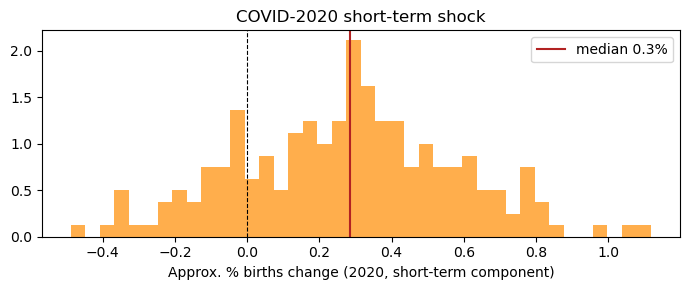

In [93]:
# Extract 2021 months from training data

idx_2021 = train[train["year"] == 2021].index.tolist()
f_sh_2021 = f_sh_post[:, idx_2021]   # (200, 12)

# Mean short-term deviation during 2021 (on log-rate scale)
mean_dev_2021 = f_sh_2021.mean(axis=1)

# Convert to approximate % change: exp(mean) - 1
pct_change = (np.exp(mean_dev_2021) - 1) * 100

print("2021 short-term component (mean over year, log-rate scale):")
print(f"  Posterior median: {np.median(mean_dev_2021):.3f}  ")
print(f"  90% CI: [{np.percentile(mean_dev_2021, 5):.3f}, {np.percentile(mean_dev_2021, 95):.3f}]")
print()
print("Approximate % births change due to short-term shock (2021):")
print(f"  Posterior median: {np.median(pct_change):.1f}%")
print(f"  90% CI: [{np.percentile(pct_change, 5):.1f}%, {np.percentile(pct_change, 95):.1f}%]")

fig, ax = plt.subplots(figsize=(7, 3))
ax.hist(pct_change, bins=40, density=True, color="darkorange", alpha=0.7)
ax.axvline(0, color="black", lw=0.8, ls="--")
ax.axvline(np.median(pct_change), color="firebrick", lw=1.5, label=f"median {np.median(pct_change):.1f}%")
ax.set_xlabel("Approx. % births change (2020, short-term component)")
ax.set_title("COVID-2020 short-term shock")
ax.legend()
plt.tight_layout()
plt.savefig(PROJ / "03_covid_shock.png", dpi=120, bbox_inches="tight")
plt.show()

## 10. Forecast 2025

The 2025 test points were included in `t_all`. Under the whitened parameterization, `z[708:]` receives no direct data gradient, so the guide posterior for these entries remains close to the prior N(0,1). The GP covariance structure encoded in the Cholesky lower rows then propagates the information from `z[:708]` to produce the correct GP-conditional predictive at test points.

In [94]:
torch.manual_seed(2026)
N_FORE = 2000   # more samples for forecast evaluation

fore = Predictive(
    additive_gp_model, guide=guide,
    num_samples=N_FORE,
    return_sites=["y", "z_trend", "z_seas", "z_short", "c",
                  "ell_trend", "sig_trend", "ell_p", "ell_s",
                  "sig_seas", "ell_short", "sig_short", "alpha"],
)(t_all, None, N_TRAIN)

# y_fore_all has shape (N_FORE, 708) — training obs only;
# for 2025 we need to sample the predictive at test points explicitly.
# Reconstruct mu at test points from z samples:

print("Computing 2025 forecast from posterior samples...")
t2 = time.time()

mu_2025_samples = []
I = torch.eye(N_ALL)

for i in range(N_FORE):
    ell_tr = fore["ell_trend"][i]
    sig_tr = fore["sig_trend"][i]
    ell_p  = fore["ell_p"][i]
    ell_s  = fore["ell_s"][i]
    sig_s  = fore["sig_seas"][i]
    ell_sh = fore["ell_short"][i]
    sig_sh = fore["sig_short"][i]
    c_i    = fore["c"][i]
    alpha_i = fore["alpha"][i]

    K_tr = sig_tr**2 * k_matern52(t_all, t_all, ell_tr) + JITTER * I
    K_se = sig_s**2  * k_periodic(t_all, t_all, ell_p) * k_rbf(t_all, t_all, ell_s) + JITTER * I
    K_sh = sig_sh**2 * k_rbf(t_all, t_all, ell_sh)     + JITTER * I

    L_tr = torch.linalg.cholesky(K_tr)
    L_se = torch.linalg.cholesky(K_se)
    L_sh = torch.linalg.cholesky(K_sh)

    f_all_i = (L_tr @ fore["z_trend"][i].squeeze()
             + L_se @ fore["z_seas"][i].squeeze()
             + L_sh @ fore["z_short"][i].squeeze())
    mu_all_i = (f_all_i + c_i).exp()
    mu_2025_samples.append(mu_all_i[N_TRAIN:].detach().numpy())   # (12,)

mu_2025 = np.array(mu_2025_samples)   # (N_FORE, 12)

# Sample NegBin counts
alpha_samples = fore["alpha"].numpy()  # (N_FORE,)
y_2025_samples = np.array([
    np.random.negative_binomial(
        alpha_samples[i],
        alpha_samples[i] / (alpha_samples[i] + mu_2025[i]),
    )
    for i in range(N_FORE)
])  # (N_FORE, 12)

print(f"Done in {time.time()-t2:.0f}s.")

gp_pred_2025 = pd.DataFrame({
    "month":  np.arange(1, 13),
    "year":   2025,
    "point":  np.median(y_2025_samples, axis=0),
    "lo80":   np.percentile(y_2025_samples, 10, axis=0),
    "hi80":   np.percentile(y_2025_samples, 90, axis=0),
    "lo95":   np.percentile(y_2025_samples, 2.5, axis=0),
    "hi95":   np.percentile(y_2025_samples, 97.5, axis=0),
    "actual": test["births"].values,
})
print(gp_pred_2025.to_string(index=False))

Computing 2025 forecast from posterior samples...
Done in 15s.
 month  year  point   lo80   hi80     lo95     hi95  actual
     1  2025 4483.5 4168.0 4812.1 4013.925 4982.100    4479
     2  2025 4325.0 4022.9 4645.2 3880.900 4828.025    4141
     3  2025 4633.5 4312.9 4971.1 4160.900 5151.000    4494
     4  2025 4699.0 4352.9 5039.1 4193.000 5241.100    4650
     5  2025 4875.0 4533.9 5211.3 4368.900 5427.050    4961
     6  2025 4903.5 4562.8 5263.0 4381.975 5471.150    4904
     7  2025 5119.0 4769.8 5507.0 4584.925 5696.025    5206
     8  2025 4957.0 4627.0 5336.1 4455.000 5518.025    5269
     9  2025 4716.0 4387.0 5072.1 4227.975 5313.075    4952
    10  2025 4558.5 4234.0 4906.1 4070.975 5097.075    4696
    11  2025 4156.0 3868.0 4461.0 3732.000 4611.000    4089
    12  2025 4035.0 3749.0 4330.0 3597.975 4507.025    3560


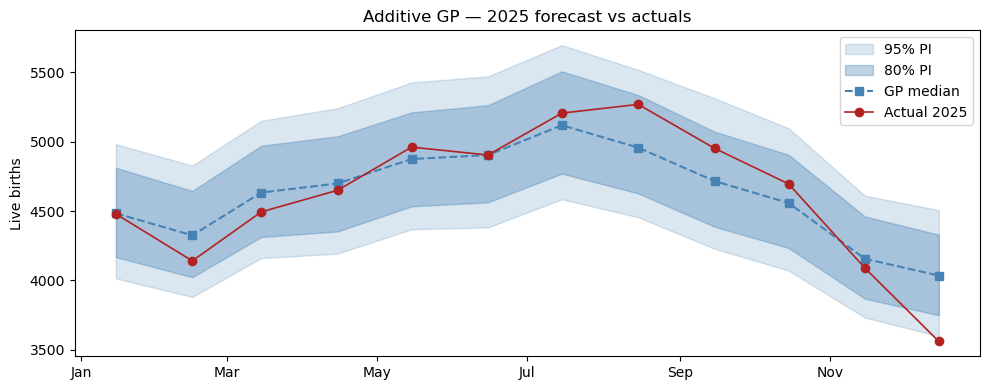

In [99]:
fig, ax = plt.subplots(figsize=(10, 4))
months_2025 = test["date"].values

ax.fill_between(months_2025, gp_pred_2025["lo95"], gp_pred_2025["hi95"],
                alpha=0.2, color="steelblue", label="95% PI")
ax.fill_between(months_2025, gp_pred_2025["lo80"], gp_pred_2025["hi80"],
                alpha=0.35, color="steelblue", label="80% PI")
ax.plot(months_2025, gp_pred_2025["point"], "s--", color="steelblue", label="GP median")
ax.plot(months_2025, gp_pred_2025["actual"], "o-", color="firebrick", lw=1.2, label="Actual 2025")

ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
ax.set_title("Additive GP — 2025 forecast vs actuals")
ax.set_ylabel("Live births")
ax.legend()
plt.tight_layout()
plt.savefig(PROJ / "03_forecast_2025.png", dpi=120, bbox_inches="tight")
plt.show()

## 11. Consolidated evaluation table

Loads baseline metrics saved by `01_baselines.ipynb` and appends the GP (SVI) result. This is the final comparison table for the report.

In [101]:
from scipy.stats import gaussian_kde

def crps_samples(y_true: np.ndarray, samples: np.ndarray) -> float:
    term1 = np.mean(np.abs(samples - y_true[np.newaxis, :]), axis=0)
    perm  = np.random.permutation(samples.shape[0])
    term2 = 0.5 * np.mean(np.abs(samples - samples[perm, :]), axis=0)
    return float(np.mean(term1 - term2))

def lpd_samples(y_true: np.ndarray, samples: np.ndarray, bw: float = 0.1) -> float:
    lpds = []
    for i, y in enumerate(y_true):
        kde = gaussian_kde(samples[:, i], bw_method=bw)
        lpds.append(float(np.log(kde(y) + 1e-300)))
    return float(np.mean(lpds))


actual = test["births"].values.astype(float)

rmse  = float(np.sqrt(np.mean((gp_pred_2025["point"].values - actual) ** 2)))
mae   = float(np.mean(np.abs(gp_pred_2025["point"].values - actual)))
crps  = crps_samples(actual, y_2025_samples)
lpd   = lpd_samples(actual, y_2025_samples)
cov80 = float(np.mean((actual >= gp_pred_2025["lo80"]) & (actual <= gp_pred_2025["hi80"])))
cov95 = float(np.mean((actual >= gp_pred_2025["lo95"]) & (actual <= gp_pred_2025["hi95"])))

gp_row = pd.DataFrame([{
    "Model": "Additive GP (SVI)",
    "RMSE":  round(rmse, 1),
    "MAE":   round(mae, 1),
    "CRPS":  round(crps, 1),
    "Cov80": round(cov80, 2),
    "Cov95": round(cov95, 2),
    "LPD":   round(lpd, 3),
}]).set_index("Model")

# Load baseline metrics saved by notebook 01 and append GP row
baseline_csv = PROJ / "01_eval_baselines.csv"
if baseline_csv.exists():
    baseline_df = pd.read_csv(baseline_csv, index_col="Model")
    eval_table  = pd.concat([baseline_df, gp_row])
else:
    print("WARNING: 01_eval_baselines.csv not found — run 01_baselines.ipynb first.")
    eval_table = gp_row

print("=" * 65)
print("Consolidated 2025 hold-out evaluation (all models)")
print("=" * 65)
print(eval_table.to_string())
print("=" * 65)
print("CRPS and LPD: lower/higher is better respectively.")
print("Cov80/Cov95: ideal = 0.80 / 0.95 (empirical coverage).")

# Save for the report
eval_table.to_csv(PROJ / "03_eval_all_models.csv")
print(f"\nSaved → 03_eval_all_models.csv")

Consolidated 2025 hold-out evaluation (all models)
                    RMSE    MAE   CRPS  Cov80  Cov95    LPD
Model                                                      
Seasonal naive     179.8  149.0  136.0   0.58   0.92 -6.953
BSTS (SVI)         381.1  317.9  227.9   0.58   0.67 -7.639
Additive GP (SVI)  198.5  148.2  114.3   0.92   0.92 -6.829
CRPS and LPD: lower/higher is better respectively.
Cov80/Cov95: ideal = 0.80 / 0.95 (empirical coverage).

Saved → 03_eval_all_models.csv


/var/folders/8_/4js4c46925s2xtwqlrvkljlm0000gn/T/ipykernel_83362/3268939793.py:13: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  lpds.append(float(np.log(kde(y) + 1e-300)))


## 12. Posterior hyperparameter summary

             median        5%       95%
param                                  
ell_trend    3.5421    3.3860    3.6916
sig_trend    0.0219    0.0211    0.0228
ell_p        0.3946    0.3682    0.4220
ell_s       74.9699   67.4137   82.4865
sig_seas     0.0377    0.0360    0.0395
ell_short    0.2056    0.0667    0.6379
sig_short    0.0016    0.0005    0.0051
c            8.5098    8.5069    8.5129
alpha      615.0500  561.1412  683.7533


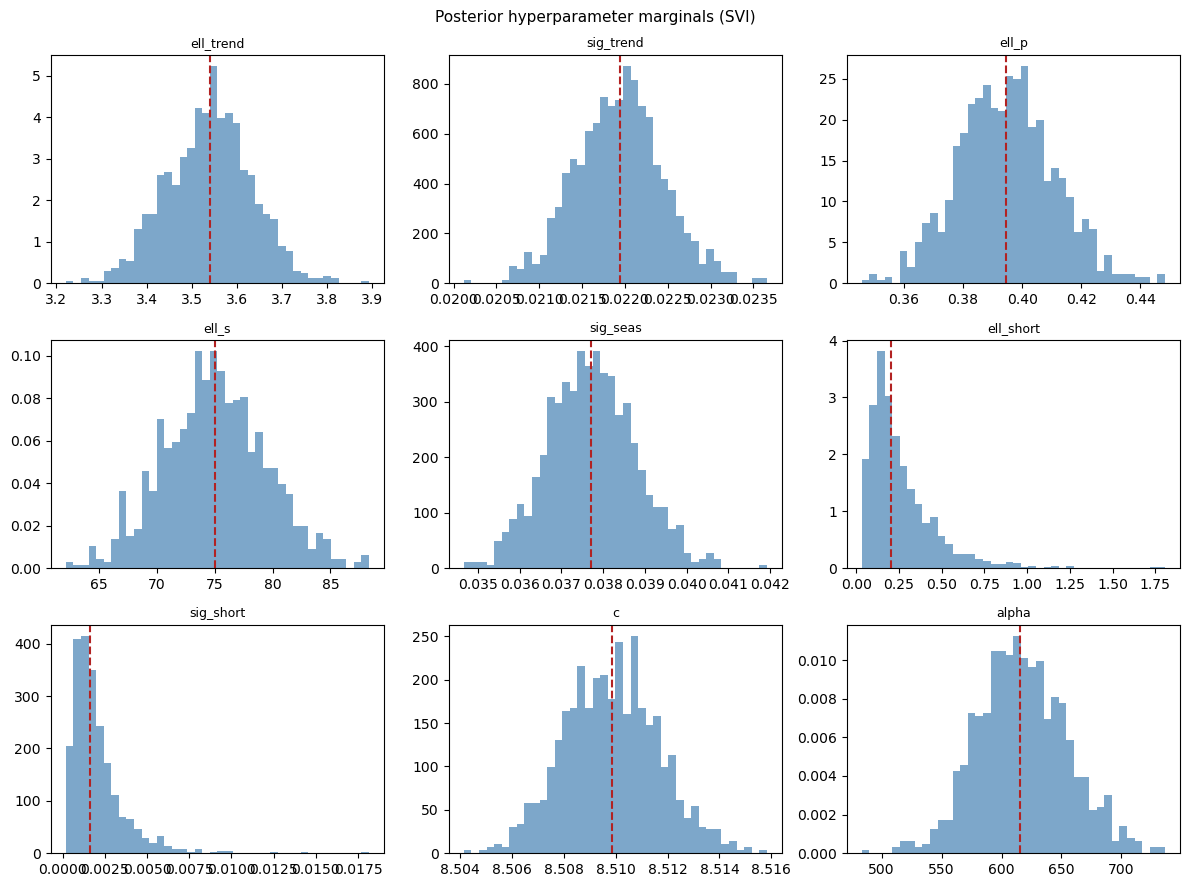

In [97]:
hp_sites = ["ell_trend", "sig_trend", "ell_p", "ell_s", "sig_seas",
            "ell_short", "sig_short", "c", "alpha"]

rows = []
for hp in hp_sites:
    s = post[hp].numpy()
    rows.append({
        "param":   hp,
        "median":  round(float(np.median(s)), 4),
        "5%":      round(float(np.percentile(s, 5)), 4),
        "95%":     round(float(np.percentile(s, 95)), 4),
    })

hp_df = pd.DataFrame(rows).set_index("param")
print(hp_df.to_string())

fig, axes = plt.subplots(3, 3, figsize=(12, 9))
for ax, hp in zip(axes.ravel(), hp_sites):
    ax.hist(post[hp].numpy(), bins=40, density=True, color="steelblue", alpha=0.7)
    ax.axvline(float(np.median(post[hp].numpy())), color="firebrick", lw=1.5, ls="--")
    ax.set_title(hp, fontsize=9)
plt.suptitle("Posterior hyperparameter marginals (SVI)", fontsize=11)
plt.tight_layout()
plt.savefig(PROJ / "03_hyperparameter_posteriors.png", dpi=120, bbox_inches="tight")
plt.show()

## 13. Summary

**Model fit:** The posterior predictive should cover the training data well; the trend should show the 1969 peak, the 1970s fertility-transition decline, the 1990s rebound, and the post-2009 decline. The seasonal component should show a recognisable spring-peak / winter-trough shape. The short-term component should show a visible 2020 dip.

**Limitations of SVI / AutoNormal (acknowledged in the report):**
- Mean-field guide ignores posterior correlations between neighbouring time points → uncertainty in the component functions is likely underestimated.
- Hyperparameter marginals are approximate. Full NUTS is the natural next step but is out of scope for this project.

**What to verify before accepting the result:**
1. ELBO convergence is monotone after the LR drop.
2. Posterior predictive 95% PI covers ≥90% of training data.
3. `ell_trend` posterior median is above 5 years.
4. The consolidated evaluation table (`03_eval_all_models.csv`) shows GP (SVI) improving on at least CRPS and LPD vs the BSTS baseline.

**Next:** Report writing — draw on `03_component_decomposition.png`, `03_forecast_2025.png`, and `03_eval_all_models.csv` as the main figures and tables.